
=== Random Forest (Multi-class IT_M_Label) ===
Accuracy: 0.9626
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      5879
           1       0.99      0.98      0.98       872
           2       0.67      0.04      0.08        91
           3       0.98      0.87      0.92       444
           4       0.90      0.63      0.74       251
           5       0.99      0.98      0.98       735

    accuracy                           0.96      8272
   macro avg       0.91      0.75      0.78      8272
weighted avg       0.96      0.96      0.96      8272



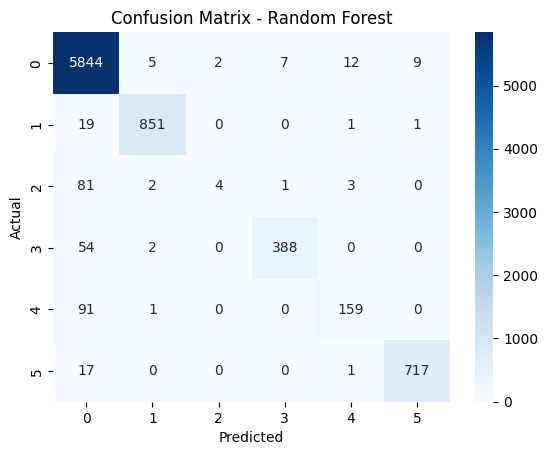


=== Random Forest (Binary IT_B_Label) ===
Accuracy: 0.9520
              precision    recall  f1-score   support

           0       0.95      0.98      0.97      5879
           1       0.95      0.88      0.91      2393

    accuracy                           0.95      8272
   macro avg       0.95      0.93      0.94      8272
weighted avg       0.95      0.95      0.95      8272



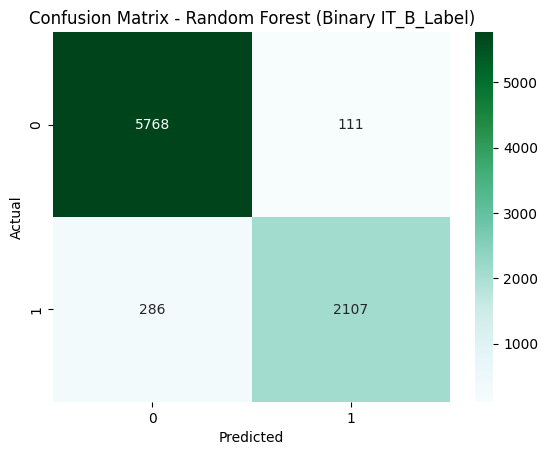


=== Isolation Forest (Binary IT_M_Label) ===
Accuracy: 0.8108
              precision    recall  f1-score   support

           0       0.79      1.00      0.88      5879
           1       0.99      0.35      0.52      2393

    accuracy                           0.81      8272
   macro avg       0.89      0.67      0.70      8272
weighted avg       0.85      0.81      0.78      8272



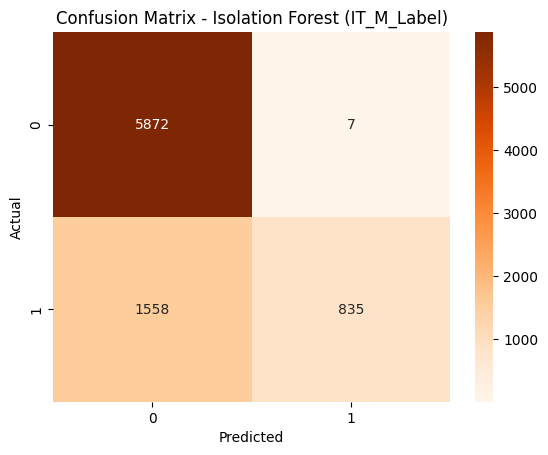


=== Isolation Forest (Binary IT_B_Label) ===
Accuracy: 0.8108
              precision    recall  f1-score   support

           0       0.79      1.00      0.88      5879
           1       0.99      0.35      0.52      2393

    accuracy                           0.81      8272
   macro avg       0.89      0.67      0.70      8272
weighted avg       0.85      0.81      0.78      8272



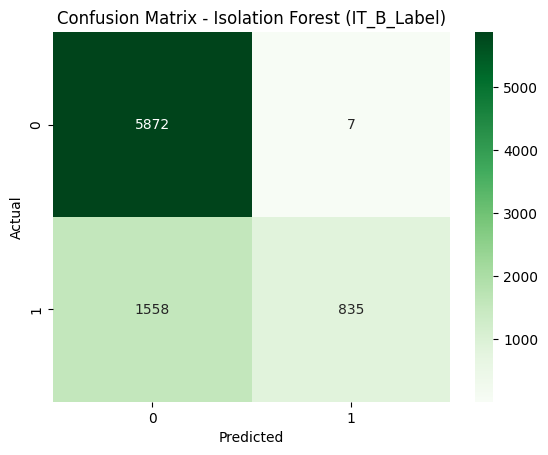


=== SVM (Multi-class IT_M_Label) ===
Accuracy: 0.8586
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      5879
           1       0.99      0.56      0.71       872
           2       0.00      0.00      0.00        91
           3       0.99      0.83      0.91       444
           4       1.00      0.02      0.03       251
           5       1.00      0.50      0.66       735

    accuracy                           0.86      8272
   macro avg       0.80      0.48      0.54      8272
weighted avg       0.87      0.86      0.83      8272



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


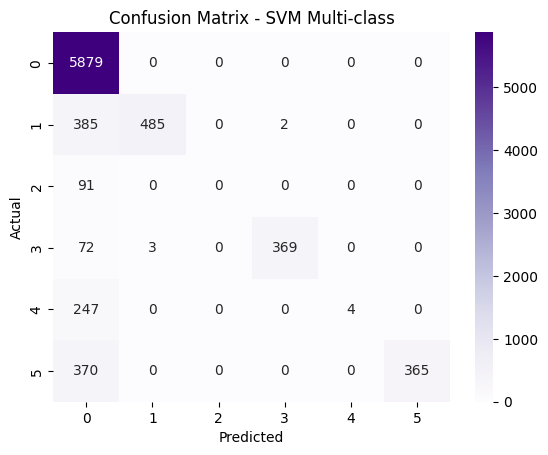


=== SVM (Binary IT_B_Label) ===
Accuracy: 0.8616
              precision    recall  f1-score   support

           0       0.84      0.99      0.91      5879
           1       0.98      0.53      0.69      2393

    accuracy                           0.86      8272
   macro avg       0.91      0.76      0.80      8272
weighted avg       0.88      0.86      0.85      8272



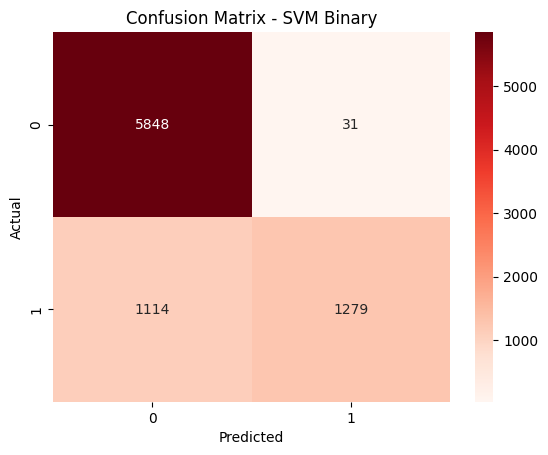


=== Final Model Accuracy Comparison ===
                                       Model  Accuracy
0                 Random Forest (IT_M_Label)  0.962645
1          Random Forest (Binary IT_B_Label)  0.952007
2  Isolation Forest (Multi-class IT_M_Label)  0.810808
3              Isolation Forest (IT_B_Label)  0.810808
4               SVM (Multi-class IT_M_Label)  0.858559
5                    SVM (Binary IT_B_Label)  0.861581


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load dataset
url = "/content/sample_data/Dataset.csv"  # Adjust path if needed
ics_data = pd.read_csv(url)

# Drop missing values
ics_data = ics_data.dropna()

# Encode categorical features
label_encoders = {}
for column in ics_data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    ics_data[column] = le.fit_transform(ics_data[column])
    label_encoders[column] = le

comparison_df = []

# ===== RANDOM FOREST (MULTI-CLASS with IT_M_Label) =====
X_rf = ics_data.drop(columns=['IT_M_Label', 'IT_B_Label'])
y_rf = ics_data['IT_M_Label']

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)
scaler_rf = StandardScaler()
X_train_rf = scaler_rf.fit_transform(X_train_rf)
X_test_rf = scaler_rf.transform(X_test_rf)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_rf, y_train_rf)
y_pred_rf = rf_model.predict(X_test_rf)

accuracy_rf = accuracy_score(y_test_rf, y_pred_rf)
comparison_df.append({'Model': 'Random Forest (IT_M_Label)', 'Accuracy': accuracy_rf})

print("\n=== Random Forest (Multi-class IT_M_Label) ===")
print(f"Accuracy: {accuracy_rf:.4f}")
print(classification_report(y_test_rf, y_pred_rf))
sns.heatmap(confusion_matrix(y_test_rf, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===== RANDOM FOREST (BINARY with IT_B_Label) =====
X_rf_bin = ics_data.drop(columns=['IT_M_Label', 'IT_B_Label'])
y_rf_bin = ics_data['IT_B_Label']

X_train_rf_bin, X_test_rf_bin, y_train_rf_bin, y_test_rf_bin = train_test_split(X_rf_bin, y_rf_bin, test_size=0.2, random_state=42)
scaler_rf_bin = StandardScaler()
X_train_rf_bin = scaler_rf_bin.fit_transform(X_train_rf_bin)
X_test_rf_bin = scaler_rf_bin.transform(X_test_rf_bin)

rf_bin_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_bin_model.fit(X_train_rf_bin, y_train_rf_bin)
y_pred_rf_bin = rf_bin_model.predict(X_test_rf_bin)

accuracy_rf_bin = accuracy_score(y_test_rf_bin, y_pred_rf_bin)
comparison_df.append({'Model': 'Random Forest (Binary IT_B_Label)', 'Accuracy': accuracy_rf_bin})

print("\n=== Random Forest (Binary IT_B_Label) ===")
print(f"Accuracy: {accuracy_rf_bin:.4f}")
print(classification_report(y_test_rf_bin, y_pred_rf_bin))
sns.heatmap(confusion_matrix(y_test_rf_bin, y_pred_rf_bin), annot=True, fmt='d', cmap='BuGn')
plt.title("Confusion Matrix - Random Forest (Binary IT_B_Label)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===== ISOLATION FOREST 1: Multi-class from IT_M_Label =====
X_iso1 = ics_data.drop(columns=['IT_M_Label', 'IT_B_Label'])
y_iso1 = np.where(ics_data['IT_M_Label'] == 0, 0, 1)

X_train_iso1, X_test_iso1, y_train_iso1, y_test_iso1 = train_test_split(X_iso1, y_iso1, test_size=0.2, random_state=42)
scaler_iso1 = StandardScaler()
X_train_iso1 = scaler_iso1.fit_transform(X_train_iso1)
X_test_iso1 = scaler_iso1.transform(X_test_iso1)

iso_model1 = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
iso_model1.fit(X_train_iso1)
y_pred_iso1 = np.where(iso_model1.predict(X_test_iso1) == 1, 0, 1)

accuracy_iso1 = accuracy_score(y_test_iso1, y_pred_iso1)
comparison_df.append({'Model': 'Isolation Forest (Multi-class IT_M_Label)', 'Accuracy': accuracy_iso1})

print("\n=== Isolation Forest (Binary IT_M_Label) ===")
print(f"Accuracy: {accuracy_iso1:.4f}")
print(classification_report(y_test_iso1, y_pred_iso1))
sns.heatmap(confusion_matrix(y_test_iso1, y_pred_iso1), annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - Isolation Forest (IT_M_Label)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===== ISOLATION FOREST 2: IT_B_Label (binary) =====
X_iso2 = ics_data.drop(columns=['IT_M_Label', 'IT_B_Label'])
y_iso2 = ics_data['IT_B_Label']

X_train_iso2, X_test_iso2, y_train_iso2, y_test_iso2 = train_test_split(X_iso2, y_iso2, test_size=0.2, random_state=42)
scaler_iso2 = StandardScaler()
X_train_iso2 = scaler_iso2.fit_transform(X_train_iso2)
X_test_iso2 = scaler_iso2.transform(X_test_iso2)

iso_model2 = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
iso_model2.fit(X_train_iso2)
y_pred_iso2 = np.where(iso_model2.predict(X_test_iso2) == 1, 0, 1)

accuracy_iso2 = accuracy_score(y_test_iso2, y_pred_iso2)
comparison_df.append({'Model': 'Isolation Forest (IT_B_Label)', 'Accuracy': accuracy_iso2})

print("\n=== Isolation Forest (Binary IT_B_Label) ===")
print(f"Accuracy: {accuracy_iso2:.4f}")
print(classification_report(y_test_iso2, y_pred_iso2))
sns.heatmap(confusion_matrix(y_test_iso2, y_pred_iso2), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Isolation Forest (IT_B_Label)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===== SVM - MULTI-CLASS (IT_M_Label) =====
X_svm_mc = ics_data.drop(columns=['IT_M_Label', 'IT_B_Label'])
y_svm_mc = ics_data['IT_M_Label']

X_train_svm_mc, X_test_svm_mc, y_train_svm_mc, y_test_svm_mc = train_test_split(X_svm_mc, y_svm_mc, test_size=0.2, random_state=42)
scaler_svm_mc = StandardScaler()
X_train_svm_mc = scaler_svm_mc.fit_transform(X_train_svm_mc)
X_test_svm_mc = scaler_svm_mc.transform(X_test_svm_mc)

svm_mc_model = SVC(kernel='rbf')
svm_mc_model.fit(X_train_svm_mc, y_train_svm_mc)
y_pred_svm_mc = svm_mc_model.predict(X_test_svm_mc)

accuracy_svm_mc = accuracy_score(y_test_svm_mc, y_pred_svm_mc)
comparison_df.append({'Model': 'SVM (Multi-class IT_M_Label)', 'Accuracy': accuracy_svm_mc})

print("\n=== SVM (Multi-class IT_M_Label) ===")
print(f"Accuracy: {accuracy_svm_mc:.4f}")
print(classification_report(y_test_svm_mc, y_pred_svm_mc))
sns.heatmap(confusion_matrix(y_test_svm_mc, y_pred_svm_mc), annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - SVM Multi-class")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===== SVM - BINARY (IT_B_Label) =====
X_svm_bin = ics_data.drop(columns=['IT_M_Label', 'IT_B_Label'])
y_svm_bin = ics_data['IT_B_Label']

X_train_svm_bin, X_test_svm_bin, y_train_svm_bin, y_test_svm_bin = train_test_split(X_svm_bin, y_svm_bin, test_size=0.2, random_state=42)
scaler_svm_bin = StandardScaler()
X_train_svm_bin = scaler_svm_bin.fit_transform(X_train_svm_bin)
X_test_svm_bin = scaler_svm_bin.transform(X_test_svm_bin)

svm_bin_model = SVC(kernel='rbf')
svm_bin_model.fit(X_train_svm_bin, y_train_svm_bin)
y_pred_svm_bin = svm_bin_model.predict(X_test_svm_bin)

accuracy_svm_bin = accuracy_score(y_test_svm_bin, y_pred_svm_bin)
comparison_df.append({'Model': 'SVM (Binary IT_B_Label)', 'Accuracy': accuracy_svm_bin})

print("\n=== SVM (Binary IT_B_Label) ===")
print(f"Accuracy: {accuracy_svm_bin:.4f}")
print(classification_report(y_test_svm_bin, y_pred_svm_bin))
sns.heatmap(confusion_matrix(y_test_svm_bin, y_pred_svm_bin), annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix - SVM Binary")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===== FINAL COMPARISON TABLE =====
comparison_df = pd.DataFrame(comparison_df)
print("\n=== Final Model Accuracy Comparison ===")
print(comparison_df)
